In [1]:
import PIL
from PIL import Image
import os
from pathlib import Path
from datasets import load_dataset, Dataset, DatasetDict

In [2]:
DATA_DIR = Path("../data/UIT_HWDB_word")

TRAIN_DIR = DATA_DIR / "train_data"
TEST_DIR = DATA_DIR / "test_data"

print(f"Train directory: {TRAIN_DIR.exists()}")
print(f"Test directory: {TEST_DIR.exists()}")

Train directory: True
Test directory: True


In [3]:
import json
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt


def load_hwdb_data(data_dir):
    """Load HWDB data from directory structure with label.json files"""
    data = []

    # Get all subdirectories
    subdirs = [d for d in data_dir.iterdir() if d.is_dir()]

    for subdir in tqdm(subdirs, desc=f"Loading from {data_dir.name}"):
        label_file = subdir / "label.json"

        if not label_file.exists():
            continue

        # Load labels
        with open(label_file, "r", encoding="utf-8") as f:
            labels = json.load(f)

        # Add each image-label pair
        for img_name, label in labels.items():
            img_path = subdir / img_name
            if img_path.exists():
                data.append(
                    {
                        "image_path": str(img_path),
                        "label": label.strip(),
                        "folder": subdir.name,
                    }
                )

    return pd.DataFrame(data)


# Load ALL data (gộp train + test)
print("Loading training data...")
train_df = load_hwdb_data(TRAIN_DIR)

print("\nLoading test data...")
test_df = load_hwdb_data(TEST_DIR)

# Combine everything
all_df = pd.concat([train_df, test_df], ignore_index=True)

print(f"\nTotal samples: {len(all_df)}")
print(f"  - From train: {len(train_df)}")
print(f"  - From test: {len(test_df)}")

Loading training data...


Loading from train_data: 100%|██████████| 249/249 [00:00<00:00, 406.63it/s]



Loading test data...


Loading from test_data: 100%|██████████| 6/6 [00:00<00:00, 278.15it/s]


Total samples: 110488
  - From train: 107607
  - From test: 2881


## Basic Data Exploration

In [4]:
# Display first few samples
print("Combined data sample:")
print(all_df.head(10))

print("\n" + "=" * 80)
print("\nRandom samples:")
print(all_df.sample(10))

Combined data sample:
                                    image_path  label folder
0   ../data/UIT_HWDB_word/train_data/112/1.jpg     Số    112
1   ../data/UIT_HWDB_word/train_data/112/2.jpg   phận    112
2   ../data/UIT_HWDB_word/train_data/112/3.jpg    của    112
3   ../data/UIT_HWDB_word/train_data/112/4.jpg  những    112
4   ../data/UIT_HWDB_word/train_data/112/5.jpg  người    112
5   ../data/UIT_HWDB_word/train_data/112/6.jpg    nói    112
6   ../data/UIT_HWDB_word/train_data/112/7.jpg    lên    112
7   ../data/UIT_HWDB_word/train_data/112/8.jpg     sự    112
8   ../data/UIT_HWDB_word/train_data/112/9.jpg   thật    112
9  ../data/UIT_HWDB_word/train_data/112/10.jpg     Ba    112


Random samples:
                                         image_path  label folder
76878   ../data/UIT_HWDB_word/train_data/144/45.jpg    cấp    144
49360    ../data/UIT_HWDB_word/train_data/212/1.jpg    Phú    212
41395   ../data/UIT_HWDB_word/train_data/180/20.jpg    hỏi    180
38830  ../data/UIT_HWDB_w

In [5]:
# Label statistics
print("=" * 80)
print("LABEL STATISTICS")
print("=" * 80)

print(f"\nTotal unique labels: {all_df['label'].nunique()}")
print(f"Total samples: {len(all_df)}")

print("\nTop 20 most frequent labels:")
print(all_df["label"].value_counts().head(20))

print("\nLabel length statistics:")
all_df["label_length"] = all_df["label"].str.len()
print(all_df["label_length"].describe())

LABEL STATISTICS

Total unique labels: 3511
Total samples: 110488

Top 20 most frequent labels:
label
có       1207
là       1123
và       1103
người    1025
của       970
không     900
một       896
được      875
công      805
đã        796
cho       704
những     679
các       669
với       643
trong     633
ở         602
đến       575
tôi       524
làm       519
lại       511
Name: count, dtype: int64

Label length statistics:
count    110488.000000
mean          3.327131
std           1.048518
min           1.000000
25%           3.000000
50%           3.000000
75%           4.000000
max          11.000000
Name: label_length, dtype: float64


## Visualize Sample Images

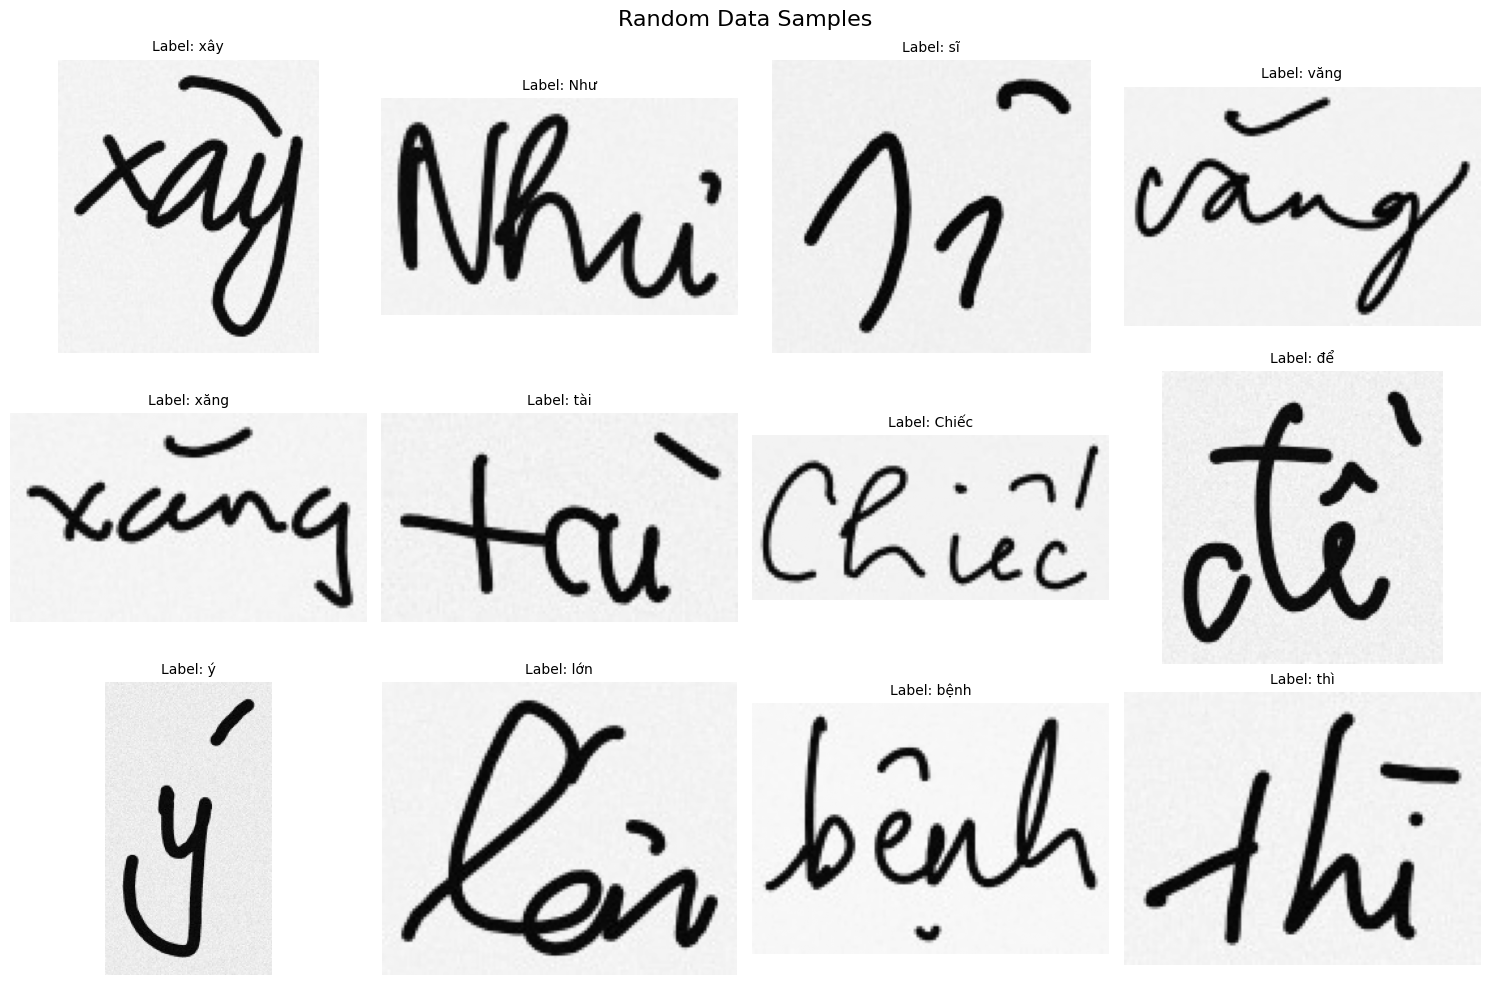

In [6]:
# Visualize random samples
def visualize_samples(df, num_samples=12, title="Sample Images"):
    fig, axes = plt.subplots(3, 4, figsize=(15, 10))
    axes = axes.flatten()

    samples = df.sample(n=num_samples)

    for idx, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row["image_path"])
        axes[idx].imshow(img, cmap="gray")
        axes[idx].set_title(f"Label: {row['label']}", fontsize=10)
        axes[idx].axis("off")

    plt.suptitle(title, fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()


visualize_samples(all_df, title="Random Data Samples")

Analyzing image dimensions...


Analyzing images: 100%|██████████| 1000/1000 [00:00<00:00, 7545.45it/s]


Image dimension statistics:
        width      height
count  1000.0  1000.00000
mean    128.0    97.39300
std       0.0    30.28828
min     128.0    34.00000
25%     128.0    76.00000
50%     128.0    93.00000
75%     128.0   112.00000
max     128.0   261.00000


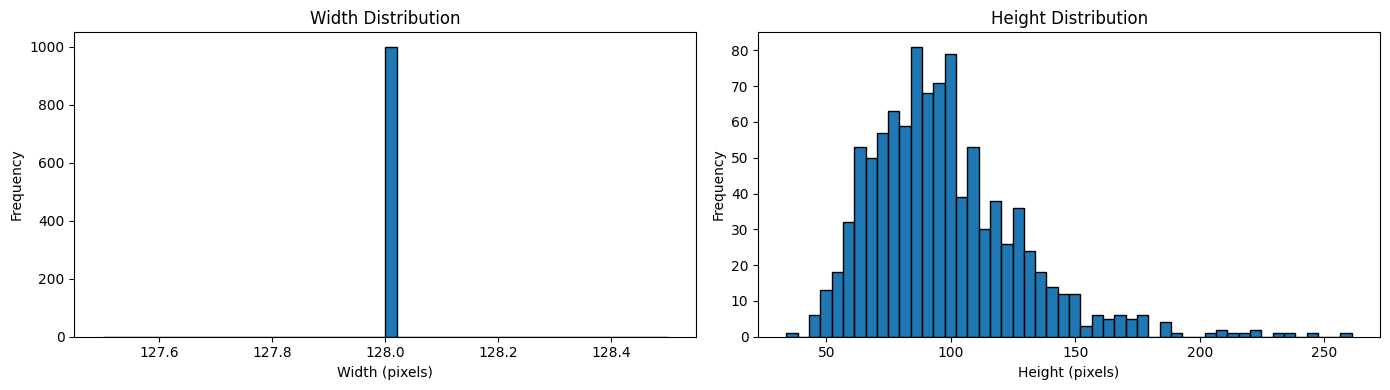

In [7]:
# Check image dimensions
def get_image_stats(df, sample_size=1000):
    sample = df.sample(n=min(sample_size, len(df)))

    widths = []
    heights = []

    for img_path in tqdm(sample["image_path"], desc="Analyzing images"):
        img = Image.open(img_path)
        widths.append(img.width)
        heights.append(img.height)

    return pd.DataFrame({"width": widths, "height": heights})


print("Analyzing image dimensions...")
img_stats = get_image_stats(all_df)

print("\nImage dimension statistics:")
print(img_stats.describe())

# Plot dimension distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(img_stats["width"], bins=50, edgecolor="black")
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Width (pixels)")
axes[0].set_ylabel("Frequency")

axes[1].hist(img_stats["height"], bins=50, edgecolor="black")
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Height (pixels)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Convert to HuggingFace Dataset

In [8]:
def df_to_hf_dataset(df):
    """Convert DataFrame to HuggingFace Dataset with images"""
    data_dict = {"image": [], "text": []}

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Converting to HF Dataset"):
        img = Image.open(row["image_path"]).convert("RGB")
        data_dict["image"].append(img)
        data_dict["text"].append(row["label"])

    return Dataset.from_dict(data_dict)


print("Converting to HuggingFace Dataset format...")
dataset = df_to_hf_dataset(all_df)

print("\nDataset structure:")
print(dataset)

print(f"\nTotal samples: {len(dataset)}")
print("\nSample from dataset:")
print(dataset[0])

Converting to HuggingFace Dataset format...


Converting to HF Dataset: 100%|██████████| 110488/110488 [00:27<00:00, 3986.15it/s]




Dataset structure:
Dataset({
    features: ['image', 'text'],
    num_rows: 110488
})

Total samples: 110488

Sample from dataset:
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=128x96 at 0x7FDCED8EF4D0>, 'text': 'Số'}


In [11]:
# Optional: Save dataset to disk for later use
dataset.save_to_disk("../data/hwdb_word_dataset")

# Or push to HuggingFace Hub
# dataset.push_to_hub("pineapplechoco/uit-hwdb-word")

Saving the dataset (0/3 shards):   0%|          | 0/110488 [00:00<?, ? examples/s]